<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Image_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

100%|██████████| 1.98G/1.98G [00:50<00:00, 42.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


### Define Data Paths

Based on the Kaggle download, the dataset is in `/kaggle/input/fruit-and-vegetable-image-recognition`. We'll assume the standard structure of `train`, `test`, and `validation` subdirectories within this path.

In [6]:
import os

dataset_root_path = path # From kagglehub.dataset_download

data_train_path = os.path.join(dataset_root_path, 'train')
data_test_path = os.path.join(dataset_root_path, 'test')
data_val_path = os.path.join(dataset_root_path, 'validation')

print(f'Training data path: {data_train_path}')
print(f'Test data path: {data_test_path}')
print(f'Validation data path: {data_val_path}')

Training data path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train
Test data path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/test
Validation data path: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/validation


### Load Image Datasets

Now, let's load the image data using `tf.keras.utils.image_dataset_from_directory`. We'll specify the image size and batch size. Make sure the subdirectories within `train`, `test`, and `validation` correspond to your image classes.

In [7]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Typically no need to shuffle validation data
)

# Load test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Typically no need to shuffle test data
)


# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of classes: {len(class_names)}")

Found 3115 files belonging to 36 classes.
Found 351 files belonging to 36 classes.
Found 359 files belonging to 36 classes.
Class names: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']
Number of classes: 36


### Visualize Sample Images

Let's display a few sample images from the training dataset to ensure everything is loaded correctly.

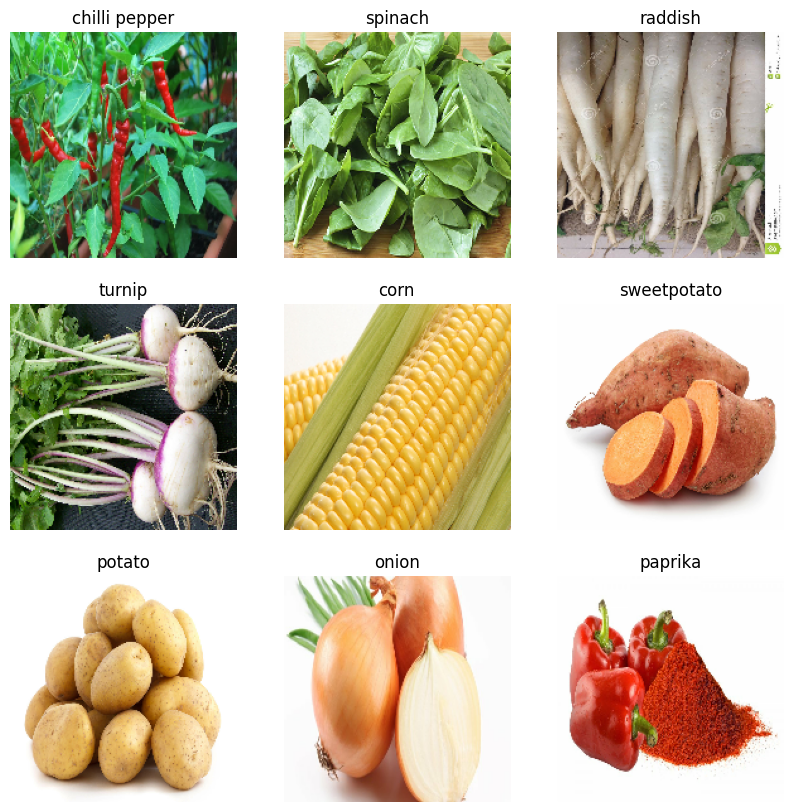

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [10]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(180,180,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(len(class_names),activation='softmax')) # Corrected for multi-class classification

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,651,620 (25.37 MB)

 Trainable params: 6,651,620 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy']) # Corrected loss identifier

In [13]:
history=model.fit(train_ds,epochs=20,validation_data=val_ds)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 676ms/step - accuracy: 0.0440 - loss: 28.5535 - val_accuracy: 0.0513 - val_loss: 3.5530
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 62s 635ms/step - accuracy: 0.0594 - loss: 3.5342 - val_accuracy: 0.1396 - val_loss: 3.4728
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 62s 629ms/step - accuracy: 0.1133 - loss: 3.3808 - val_accuracy: 0.2108 - val_loss: 3.2643
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 636ms/step - accuracy: 0.2180 - loss: 2.9825 - val_accuracy: 0.4103 - val_loss: 2.6088
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 62s 639ms/step - accuracy: 0.3618 - loss: 2.4630 - val_accuracy: 0.4843 - val_loss: 2.3200
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 621ms/step - accuracy: 0.4626 - loss: 2.1399 - val_accuracy: 0.5670 - val_loss: 1.8837
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 65s 661ms/step - accuracy: 0.5676 - loss: 1.7208 - val_accuracy: 0.6410 - val_loss: 2.0429
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 80s 642ms/step - accuracy: 0.6491 - loss: 1.5124 - val_acc

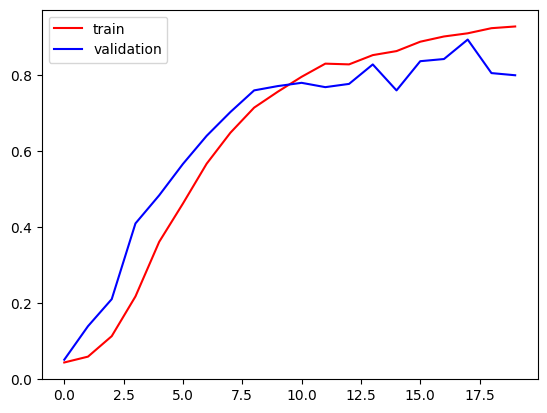

In [14]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [21]:
image='grapes.jpg'
image=tf.keras.utils.load_img(image,target_size=(180,180))
image_arr=tf.keras.utils.img_to_array(image)
image_bat=tf.expand_dims(image_arr,0) # Add batch dimension

predictions=model.predict(image_bat) # Get raw predictions (probabilities, since last layer is softmax)

# The output of model.predict for a softmax layer is already probabilities
score = predictions[0]

predicted_class_index = np.argmax(score)
predicted_class_name = class_names[predicted_class_index]
predicted_probability = score[predicted_class_index] * 100

print(f"Predictions (probabilities for each class): {score}")
print(f"The image is predicted to be a '{predicted_class_name}' with {predicted_probability:.2f}% confidence.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predictions (probabilities for each class): [1.6834642e-10 3.7658585e-33 3.1684260e-18 5.8674574e-21 3.3575877e-24
 6.3209032e-27 1.4416782e-20 1.1020393e-26 8.9751010e-15 1.6558848e-26
 3.4628303e-19 3.8791942e-18 1.9309393e-19 9.3590959e-27 1.0000000e+00
 3.0722662e-19 1.8109480e-20 2.3355669e-31 2.1443941e-27 3.6222370e-27
 5.0463737e-18 2.4546945e-23 1.6682012e-29 2.8304936e-15 2.2404221e-21
 6.4374926e-18 5.1762039e-18 2.3779674e-21 4.7534972e-21 1.0129908e-26
 1.4690634e-29 2.3887010e-24 3.5979511e-16 9.2002410e-32 7.7138631e-21
 4.2975088e-13]
The image is predicted to be a 'grapes' with 100.00% confidence.


In [24]:
model.save('Image_classify.keras')